# Session 3 — Monte Carlo for Decision-Making & Risk

**Course:** Decision Modelling — Simulation Part
**Session:** 3 of 12 (simulation portion)

## Learning objectives

By the end of this session you should be able to:

- Build a complete Monte Carlo (MC) simulation model from scratch
- Compute both **point estimates** and **interval estimates** of a decision's performance
- Quantify **risk**, not just expected performance, using standard deviation, probability of loss, VaR, and CVaR
- Compare decision alternatives and recognize when independent simulation runs make that comparison noisy

## Where this session fits

- **Looking back:** Session 1 introduced MC thinking informally (a random arrival process, the Law of Large Numbers). Session 2 gave you the tool to turn real data into a *justified* input distribution rather than a guess.
- **Today:** we assemble both into a full decision-relevant MC model — the classic **Newsvendor problem** — learn to report results with **confidence intervals** rather than bare averages, and go beyond the mean to quantify risk. We also get a first taste of why *how* you compare two alternatives matters, using **Common Random Numbers (CRN)** — a topic Session 10 treats fully and rigorously.
- **Looking ahead:** everything in this session models a **static, one-shot decision** — order quantity `q` is chosen once, demand is realized once. Session 4 asks what happens when a decision problem doesn't reduce to a single number, but instead **evolves over time** — a process with flow, queues, and time-dependent state. That's the shift from Monte Carlo to the flow/queueing/DES track that carries the rest of the course.



## Further reading (supplementary, not required)

- A chapter or tutorial on Monte Carlo methods for decision analysis under uncertainty — check the course reading list for the current reference.
- The Newsvendor problem is one of the most studied models in operations management; if you want more background on the underlying economics (critical ratio, overage/underage cost), any standard OM textbook covers it — we derive what we need from first principles below.
- A focused reference on Common Random Numbers as a variance-reduction technique — we only preview the idea today; Session 10 gives it a full, formal treatment.



## 1. The Monte Carlo workflow

A Monte Carlo simulation model, in general, follows this pattern:

1. **Define the decision/question** — what are we trying to evaluate or choose?
2. **Specify the uncertain inputs** — as distributions (ideally justified the way Session 2 showed, e.g. fitted to real data)
3. **For each replication:** sample the uncertain inputs, compute the resulting output (profit, cost, service level, ...)
4. **Aggregate across replications** — the outputs from many replications form a *distribution*, not a single number
5. **Report a point estimate** (e.g. the sample mean) **and an interval estimate** (a confidence interval) — a single number without an indication of its precision is not enough for a decision
6. **Use the results to compare or choose** between decisions, and be honest about risk, not just the average outcome

We build all six steps today, end to end.



## 2. The Newsvendor problem

**Decision framing:** A vendor must decide how many units, `q`, to order *before* observing actual demand, `D`. Demand is uncertain. Once demand is realized:

- Units sold = `min(q, D)`
- Leftover (unsold) units = `max(q - D, 0)`, which are scrapped/salvaged at a reduced value
- If demand exceeds `q`, the excess demand is simply lost (no backorders in this basic version)

**Parameters** (reusing real, previously-used course figures):

| Parameter | Symbol | Value |
|---|---|---|
| Wholesale (purchase) cost per unit | `c` | 0.55 |
| Retail (selling) price per unit | `r` | 1.00 |
| Salvage/scrap value per leftover unit | `s` | 0.03 |
| Demand distribution | `D ~ Normal(mu, sigma)` | mu = 135.7, sigma = 27.1 |

**Profit for a single realization of demand:**

```
sold   = min(q, D)
scrap  = q - sold
profit = r * sold + s * scrap - c * q
```

This is exactly the kind of overage/underage trade-off simulation is well suited to evaluate: order too little (`q` small) and you leave money on the table from lost sales; order too much (`q` large) and you eat the cost of unsold, salvaged units. There's a well-known analytical "critical ratio" formula for the profit-maximizing `q` under a Normal demand assumption — we're deliberately not using it yet. Building the simulation first, and only later checking it against the analytical answer, mirrors exactly the **verification** mindset you'll formalize in Session 12.



## 3. Hands-on: simulating a single day, then many replications

We start small: simulate *one* day's outcome for a fixed order quantity, then scale up to many replications (the actual Monte Carlo step).



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Newsvendor parameters
c = 0.55       # wholesale cost per unit
r = 1.00       # retail price per unit
s = 0.03       # salvage value per leftover unit
mu_demand = 135.7
sigma_demand = 27.1

rng = np.random.default_rng(seed=42)

def simulate_one_day(q, rng):
    demand = rng.normal(mu_demand, sigma_demand)
    demand = max(demand, 0)  # demand can't be negative
    sold = min(q, demand)
    scrap = q - sold
    profit = r * sold + s * scrap - c * q
    return profit

# A single day, for a trial order quantity
q_trial = 140
one_day_profit = simulate_one_day(q_trial, rng)
print(f"Profit for a single simulated day (q={q_trial}): {one_day_profit:.2f}")

Profit for a single simulated day (q=140): 63.00


A single day tells us almost nothing about how good `q = 140` is — it's one noisy draw. This is exactly the Session 1 lesson: we need **many replications** and the Law of Large Numbers to get a trustworthy estimate.



Mean profit over 1000 replications: 50.12
Std dev of profit: 17.07


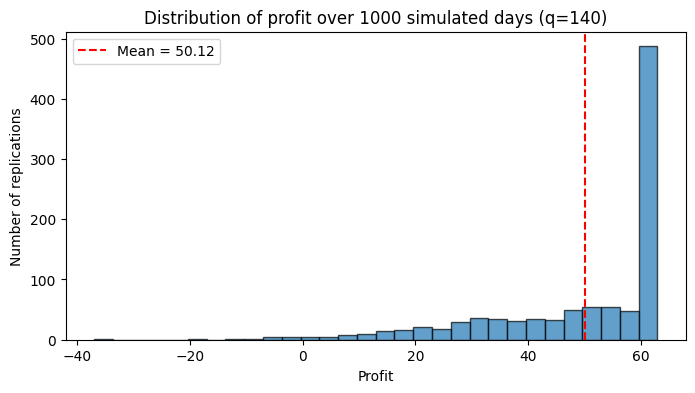

In [2]:
def simulate_newsvendor(q, n_reps, rng):
    profits = np.empty(n_reps)
    for i in range(n_reps):
        profits[i] = simulate_one_day(q, rng)
    return profits

n_reps = 1000
profits = simulate_newsvendor(q_trial, n_reps, rng)

print(f"Mean profit over {n_reps} replications: {profits.mean():.2f}")
print(f"Std dev of profit: {profits.std(ddof=1):.2f}")

plt.figure(figsize=(8, 4))
plt.hist(profits, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(profits.mean(), color='red', linestyle='--', label=f'Mean = {profits.mean():.2f}')
plt.xlabel('Profit')
plt.ylabel('Number of replications')
plt.title(f'Distribution of profit over {n_reps} simulated days (q={q_trial})')
plt.legend()
plt.show()

## 4. Point estimates aren't enough: confidence intervals

The sample mean above is a **point estimate** — a single best guess. But it came from a *finite* number of replications, so it has sampling error. A **confidence interval (CI)** quantifies that uncertainty: "we are 95% confident the true mean profit lies within this range," given our simulation's randomness.

For a sample of `n` i.i.d. replications with sample mean `x̄` and sample standard deviation `s`, the standard (large-sample / t-based) CI for the mean is:

```
x̄  ±  t(n-1, 1-alpha/2) * s / sqrt(n)
```

This is directly analogous to the confidence intervals you already know from statistics — we're just applying it to *simulation output* instead of a physical measurement.



In [3]:
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    sem = data.std(ddof=1) / np.sqrt(n)  # standard error of the mean
    t_crit = stats.t.ppf((1 + confidence) / 2, df=n - 1)
    half_width = t_crit * sem
    return mean, mean - half_width, mean + half_width

mean_profit, ci_low, ci_high = confidence_interval(profits)
print(f"Point estimate: {mean_profit:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]  (half-width = {mean_profit - ci_low:.2f})")

Point estimate: 50.12
95% CI: [49.06, 51.18]  (half-width = 1.06)


### Discussion: how many replications do we actually need?

Try re-running the cell above with `n_reps = 100` instead of 1000 (change it in Section 3 and re-run). What happens to the width of the confidence interval? This trade-off — more replications narrow the CI but cost more computation time — is exactly what Session 8 (Output Analysis for Terminating Simulations) formalizes into a method for *choosing* the number of replications, rather than picking a round number by feel.



## 5. Propagating uncertainty across decisions: profit vs. order quantity

A single `q` in isolation isn't very actionable — the real decision question is: **how does expected profit (and its uncertainty) change as we vary `q`?** Let's evaluate the same order quantities used in the original course material: `q ∈ {100, 120, 140, 160, 180}`.



     q  mean_profit  ci_low  ci_high
0  100        43.62   43.39    43.85
1  120        49.49   49.06    49.93
2  140        50.52   49.78    51.25
3  160        45.61   44.64    46.59
4  180        36.66   35.54    37.78

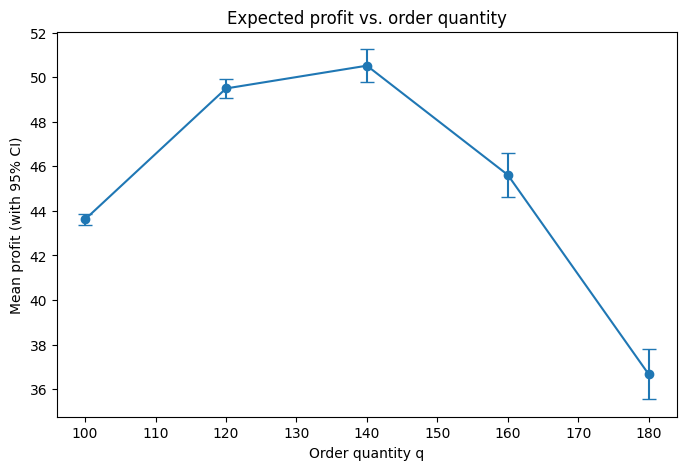

In [4]:
q_values = [100, 120, 140, 160, 180]
n_reps = 2000

results = []
for q in q_values:
    profits_q = simulate_newsvendor(q, n_reps, rng)
    mean_q, low_q, high_q = confidence_interval(profits_q)
    results.append({
        'q': q,
        'mean_profit': mean_q,
        'ci_low': low_q,
        'ci_high': high_q
    })

results_df = pd.DataFrame(results)
print(results_df.round(2))

plt.figure(figsize=(8, 5))
plt.errorbar(
    results_df['q'], results_df['mean_profit'],
    yerr=[results_df['mean_profit'] - results_df['ci_low'], results_df['ci_high'] - results_df['mean_profit']],
    fmt='o-', capsize=5
)
plt.xlabel('Order quantity q')
plt.ylabel('Mean profit (with 95% CI)')
plt.title('Expected profit vs. order quantity')
plt.show()

Notice something important: comparing these `q` values by simply looking at point estimates risks over-interpreting small differences that may just be simulation noise. **Are the confidence intervals for neighboring `q` values overlapping?** If so, we can't yet claim one is definitively better than another from independent runs alone — Section 7 below shows why, and previews a sharper way to compare (Common Random Numbers), which Session 10 treats in full.



## 6. Beyond the mean: quantifying risk

Expected profit tells only part of the story. Two order quantities could have the *same* expected profit but very different **risk** profiles — one might have a tight, predictable distribution of outcomes, while the other swings wildly between great days and bad ones. A risk-aware decision-maker needs more than a single number.

Common risk metrics, applied directly to simulation output:

| Metric | What it measures | How to compute from simulation output |
|---|---|---|
| **Standard deviation** | Overall spread/volatility of outcomes | `profits.std()` |
| **Probability of a loss** | How often the outcome is below some threshold (e.g. 0, or a target) | `(profits < threshold).mean()` |
| **Value-at-Risk (VaR)** | The outcome such that there's only an alpha% chance of doing worse (a lower percentile) | `np.percentile(profits, alpha)` |
| **Conditional VaR (CVaR) / Expected Shortfall** | The *average* outcome, given that you're already in the bad-outcome tail | mean of `profits` values at or below the VaR threshold |

None of these require new simulation machinery — they're all just different ways of summarizing the same replicated output we already know how to generate.



In [5]:
def risk_metrics(profits, var_alpha=5):
    mean_profit = profits.mean()
    std_profit = profits.std(ddof=1)
    prob_loss = (profits < 0).mean()
    var = np.percentile(profits, var_alpha)          # e.g. 5th percentile -> 95% VaR
    cvar = profits[profits <= var].mean()
    return {
        'mean': mean_profit,
        'std': std_profit,
        'prob_loss': prob_loss,
        f'VaR_{var_alpha}%': var,
        f'CVaR_{var_alpha}%': cvar
    }

profits_140 = simulate_newsvendor(140, 5000, rng)
profits_180 = simulate_newsvendor(180, 5000, rng)

metrics_140 = risk_metrics(profits_140)
metrics_180 = risk_metrics(profits_180)

comparison = pd.DataFrame([metrics_140, metrics_180], index=['q=140', 'q=180']).round(2)
print(comparison)

        mean    std  prob_loss  VaR_5%  CVaR_5%
q=140  50.19  16.50       0.01   16.30     5.85
q=180  38.72  25.25       0.07   -4.11   -15.40


Look closely at `q=180` vs `q=140`: a larger order quantity means more units at risk of going unsold, which typically **increases** downside exposure even if the mean profit is still reasonable. This is exactly the kind of trade-off risk metrics surface that a mean-only comparison would hide.



## 7. Comparing alternatives: why independent runs can mislead you

Section 5 compared `q` values using **independent** simulation runs for each — the natural first instinct. It has a hidden cost: any difference we observe between two order quantities is mixed together with simulation noise from *both* runs, since each used different random demand draws. Let's make this precise for `q=140` vs. `q=160`.



In [6]:
n_reps = 500

# Independent runs: separate random draws for each q
profits_140_indep = simulate_newsvendor(140, n_reps, rng)
profits_160_indep = simulate_newsvendor(160, n_reps, rng)

diff_indep = profits_140_indep.mean() - profits_160_indep.mean()

se_indep = np.sqrt(profits_140_indep.var(ddof=1) / n_reps + profits_160_indep.var(ddof=1) / n_reps)
t_crit = stats.t.ppf(0.975, df=n_reps - 1)
ci_half_width_indep = t_crit * se_indep

print(f"Independent comparison: mean(q=140) - mean(q=160) = {diff_indep:.3f}")
print(f"95% CI half-width: {ci_half_width_indep:.3f}")

Independent comparison: mean(q=140) - mean(q=160) = 3.643
95% CI half-width: 2.490


**A sharper alternative (preview only):** if we used the *same* sequence of random demand draws for both `q=140` and `q=160` — an idea called **Common Random Numbers (CRN)** — differences between the two would be driven only by the difference in `q`, not by one policy getting luckier demand than the other. That typically makes the comparison's confidence interval noticeably *narrower* for the same simulation budget. We're not building the machinery for this today — Session 10 (Scenario Comparison & Variance Reduction Methods) gives CRN a full, rigorous treatment alongside other variance-reduction techniques and formal statistical tests. For now, just register the idea: **how** you compare two alternatives matters, not just how many replications you run.



## Exercise (guided): finding q for a target service level

The operations manager tells you they want a **service level** (probability that demand is fully met without a stockout) of **at least 90%** and asks: "what's the smallest order quantity that achieves that, and what expected profit does it give up compared to the profit-maximizing quantity we found in Section 5?"

Your task:

1. Simulate service level and mean profit for a finer grid of `q` values, e.g. `range(120, 181, 5)`
2. Find the smallest `q` in your grid with an estimated service level ≥ 0.90
3. Compare its mean profit (with CI) to the best `q` found in Section 5
4. State, in a sentence, the profit "cost" of this service-level guarantee



In [7]:
# EXERCISE
def simulate_newsvendor_with_service_level(q, n_reps, rng):
    profits = np.empty(n_reps)
    stockout = np.empty(n_reps, dtype=bool)
    for i in range(n_reps):
        demand = max(rng.normal(mu_demand, sigma_demand), 0)
        sold = min(q, demand)
        scrap = q - sold
        profits[i] = r * sold + s * scrap - c * q
        stockout[i] = demand > q
    return profits, stockout

q_grid = list(range(120, 181, 5))
n_reps = 2000

# TODO: for each q in q_grid, simulate profits and stockout indicators,
#       then compute mean profit, CI, and service level; store in a DataFrame

# TODO: find the smallest q with service level >= 0.90

# TODO: compare its mean profit (and CI) to the best q from Section 5

# TODO: print a one-sentence conclusion about the profit cost of the service-level target

<details>
<summary>Solution (click to expand)</summary>

```python
# SOLUTION
q_grid = list(range(120, 181, 5))
n_reps = 2000

rows = []
for q in q_grid:
    profits_q, stockout_q = simulate_newsvendor_with_service_level(q, n_reps, rng)
    mean_q, low_q, high_q = confidence_interval(profits_q)
    service_level_q = 1 - stockout_q.mean()
    rows.append({
        'q': q, 'mean_profit': mean_q, 'ci_low': low_q, 'ci_high': high_q,
        'service_level': service_level_q
    })

grid_df = pd.DataFrame(rows)
print(grid_df.round(3))

qualifying = grid_df[grid_df['service_level'] >= 0.90]
best_service_q = qualifying.iloc[0]  # smallest q meeting the target, since q_grid is sorted
best_overall = grid_df.loc[grid_df['mean_profit'].idxmax()]

print(f"\nSmallest q with service level >= 90%: q = {best_service_q['q']:.0f}, "
      f"mean profit = {best_service_q['mean_profit']:.2f}")
print(f"Best q by mean profit alone: q = {best_overall['q']:.0f}, "
      f"mean profit = {best_overall['mean_profit']:.2f}")

profit_gap = best_overall['mean_profit'] - best_service_q['mean_profit']
print(f"\nConclusion: guaranteeing a 90% service level costs about {profit_gap:.2f} "
      f"in expected profit per day compared to the profit-maximizing order quantity.")
```
</details>



### Discussion questions

1. Session 2 gave us tools to *justify* the Normal(135.7, 27.1) demand assumption from data. What would you want to check before trusting this Monte Carlo model's conclusions for a real decision?
2. We used `n_reps` values throughout somewhat arbitrarily (1000, 2000, 5000...). What evidence in this notebook would help you argue whether a given number is "enough"? (Session 8 formalizes this.)
3. Is it possible for a decision to have *higher* expected profit but *worse* risk (e.g. a higher probability of loss)? What would you tell a risk-averse decision-maker in that case?
4. Every model in this session makes a single decision (`q`) once, and the "system" disappears after one day's demand is realized. Can you think of an OSCM decision that *doesn't* fit this mold — where the system keeps running, state accumulates, and today's decision affects tomorrow's starting point? Keep this in mind for Session 4.



## Wrap-up

Today we:

- Formalized the general Monte Carlo workflow: define → specify inputs → replicate → aggregate → report with uncertainty → decide
- Built a complete Newsvendor Monte Carlo model from real course parameters
- Learned to report **point estimates together with confidence intervals**, not bare averages
- Propagated uncertainty across a range of order quantities and visualized profit vs. `q` with CIs
- Computed a second decision-relevant output (service level) from the same simulation
- Went beyond the mean: standard deviation, probability of loss, VaR, and CVaR
- Saw why comparing alternatives via independent runs is noisier than it needs to be, and previewed Common Random Numbers as the fix (full treatment: Session 10)

**Next session:** Quantifying Flow: Capacity & Cycle Time — every model today made a single, static decision. Many real OSCM systems instead *evolve continuously over time* — work arrives, queues form, resources are shared. We'll put precise numbers on the WIP/TH/CT vocabulary from Session 1 and start building the flow/capacity toolkit that queueing theory (Session 5) and Discrete-Event Simulation (Session 6 onward) both build on.

